# Jupyter Notebook Starter Placeholder
This notebook will contain future data exploration and model training logic.

In [1]:
import pickle
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import (accuracy_score, confusion_matrix,
                             classification_report, ConfusionMatrixDisplay)

with open("../models/model_notebook.pkl", "rb") as f:
    model = pickle.load(f)

test = pd.read_csv("../data/processed/test.csv")
X_test, y_test = test.drop("Outcome", axis=1), test["Outcome"]
y_pred = model.predict(X_test)
print("Accuracy:", round(accuracy_score(y_test, y_pred) * 100, 2), "%")

Accuracy: 86.36 %


In [2]:
print(classification_report(y_test, y_pred, target_names=["No Diabetes", "Diabetes"]))

              precision    recall  f1-score   support

 No Diabetes       0.89      0.90      0.90       100
    Diabetes       0.81      0.80      0.80        54

    accuracy                           0.86       154
   macro avg       0.85      0.85      0.85       154
weighted avg       0.86      0.86      0.86       154



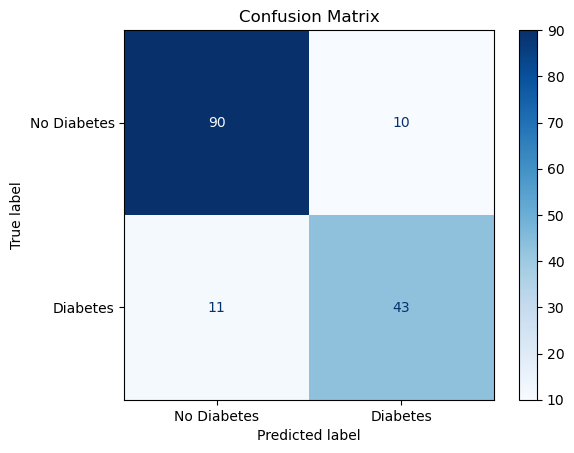

In [3]:
# Diagonal values are correct predictions, the rest are mistakes
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=["No Diabetes", "Diabetes"]).plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

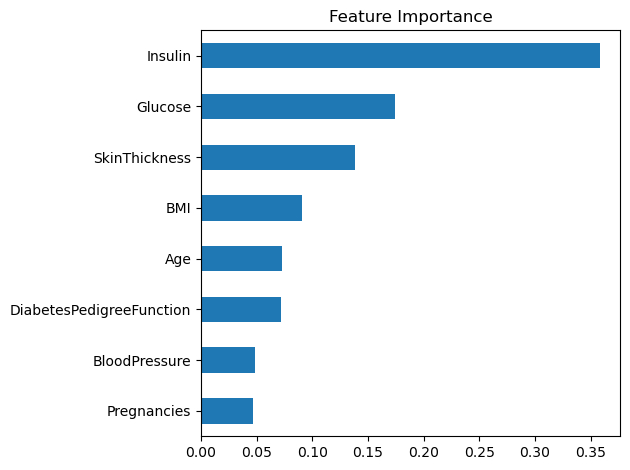

Insulin                     0.358367
Glucose                     0.173985
SkinThickness               0.138629
BMI                         0.090195
Age                         0.072941
DiabetesPedigreeFunction    0.071559
BloodPressure               0.048064
Pregnancies                 0.046260
dtype: float64


In [4]:
# Which features the model relies on most
imp = pd.Series(model.feature_importances_, index=X_test.columns).sort_values()
imp.plot(kind="barh", title="Feature Importance")
plt.tight_layout()
plt.show()
print(imp.sort_values(ascending=False))